In [1]:
from warnings import filterwarnings; filterwarnings("ignore")
import joblib
import pandas as pd
import numpy as np
import pandas, numpy
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor, Pool
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import StackingRegressor

from sklearn.linear_model import RidgeCV
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import LassoLars

from sklearn.metrics import mean_absolute_percentage_error
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.ensemble import VotingRegressor, BaggingRegressor
from sklearn.base import BaseEstimator, RegressorMixin
from scipy.optimize import minimize
from sklearn.metrics import r2_score

In [2]:
class DataPreprocessing:
    def __init__(self, train, test):
        self.target = "ghi"
        self.column_drop = "timestamp"
        
        self.train_original = train.copy()
        self.test_original = test.copy()
        
        if 'Unnamed: 0' in train.columns:
            self.train = train.drop(columns=['Unnamed: 0'])
            self.test = test.drop(columns=['Unnamed: 0'])
        else:
            self.train = train.copy()
            self.test = test.copy()

        self.train = self.train.dropna(subset=['timestamp'])
        self.test = self.test.dropna(subset=['timestamp'])

        self.feature_extraction()
        self.handle_solar_specific_features()
        self.handle_missing_values()
        self.train_test_split()
        self.normalise_encode()
        
    def feature_extraction(self):
        """Advanced feature extraction for solar forecasting with astronomical and meteorological features"""
        
        self.train['timestamp'] = pd.to_datetime(self.train['timestamp'])
        self.test['timestamp'] = pd.to_datetime(self.test['timestamp'])
        
        for df in [self.train, self.test]:
            df['timestamp_year'] = df['timestamp'].dt.year
            df['timestamp_month'] = df['timestamp'].dt.month
            df['timestamp_day'] = df['timestamp'].dt.day
            df['timestamp_hour'] = df['timestamp'].dt.hour
            df['timestamp_minute'] = df['timestamp'].dt.minute
            
            df['day_of_year'] = df['timestamp'].dt.dayofyear
            df['week_of_year'] = df['timestamp'].dt.isocalendar().week
            df['day_of_week'] = df['timestamp'].dt.dayofweek
            df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
            df['quarter'] = df['timestamp'].dt.quarter
            
            df['is_morning'] = ((df['timestamp_hour'] >= 6) & (df['timestamp_hour'] < 12)).astype(int)
            df['is_afternoon'] = ((df['timestamp_hour'] >= 12) & (df['timestamp_hour'] < 18)).astype(int)
            df['is_evening'] = ((df['timestamp_hour'] >= 18) & (df['timestamp_hour'] < 22)).astype(int)
            df['is_night'] = ((df['timestamp_hour'] >= 22) | (df['timestamp_hour'] < 6)).astype(int)
            
            df['is_peak_solar'] = ((df['timestamp_hour'] >= 10) & (df['timestamp_hour'] <= 16)).astype(int)
            df['hours_from_solar_noon'] = np.abs(df['timestamp_hour'] - 12)
            
            df['hour_sin'] = np.sin(2 * np.pi * df['timestamp_hour'] / 24)
            df['hour_cos'] = np.cos(2 * np.pi * df['timestamp_hour'] / 24)
            df['day_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
            df['day_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)
            df['month_sin'] = np.sin(2 * np.pi * df['timestamp_month'] / 12)
            df['month_cos'] = np.cos(2 * np.pi * df['timestamp_month'] / 12)
            df['week_sin'] = np.sin(2 * np.pi * df['week_of_year'] / 52)
            df['week_cos'] = np.cos(2 * np.pi * df['week_of_year'] / 52)
            df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
            df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
            
            df['season'] = ((df['timestamp_month'] % 12) // 3)
            
            df['is_summer'] = (df['season'] == 1).astype(int)
            df['is_winter'] = (df['season'] == 3).astype(int)
            df['is_spring'] = (df['season'] == 0).astype(int)
            df['is_autumn'] = (df['season'] == 2).astype(int)
            
            df['is_monsoon'] = ((df['timestamp_month'] >= 6) & (df['timestamp_month'] <= 9)).astype(int)
            df['is_winter_solstice_period'] = ((df['timestamp_month'] == 12) | (df['timestamp_month'] == 1)).astype(int)
            df['is_summer_solstice_period'] = ((df['timestamp_month'] == 6) | (df['timestamp_month'] == 7)).astype(int)
            df['is_equinox_period'] = ((df['timestamp_month'] == 3) | (df['timestamp_month'] == 9)).astype(int)
            
            df['solar_declination'] = 23.45 * np.sin(np.radians(360 * (284 + df['day_of_year']) / 365))
            
            df['hour_angle'] = 15 * (df['timestamp_hour'] - 12)
            
            latitude = 23.0
            df['solar_elevation'] = np.arcsin(
                np.sin(np.radians(latitude)) * np.sin(np.radians(df['solar_declination'])) +
                np.cos(np.radians(latitude)) * np.cos(np.radians(df['solar_declination'])) * 
                np.cos(np.radians(df['hour_angle']))
            ) * 180 / np.pi
            
            df['solar_elevation_positive'] = np.maximum(df['solar_elevation'], 0)
            
            df['air_mass'] = np.where(
                df['solar_elevation_positive'] > 0,
                1 / (np.sin(np.radians(df['solar_elevation_positive'])) + 
                     0.50572 * (df['solar_elevation_positive'] + 6.07995) ** -1.6364),
                np.inf
            )
            df['air_mass'] = np.where(df['air_mass'] == np.inf, 50, df['air_mass'])
            df['air_mass'] = np.minimum(df['air_mass'], 50)
            
            solar_constant = 1367
            df['extraterrestrial_radiation'] = solar_constant * (
                1 + 0.033 * np.cos(2 * np.pi * df['day_of_year'] / 365)
            ) * np.maximum(np.sin(np.radians(df['solar_elevation'])), 0)
            
            df['theoretical_clear_sky_ghi'] = df['extraterrestrial_radiation'] * 0.75 ** (df['air_mass'] ** 0.678)
            
            turbidity_factor = 2.0
            
            rayleigh_coefficient = np.where(df['air_mass'] <= 20, 
                                          1 / (6.6296 + 1.7513 * df['air_mass'] - 0.1202 * df['air_mass']**2 + 
                                               0.0065 * df['air_mass']**3 - 0.00013 * df['air_mass']**4), 0)
            
            aerosol_coefficient = np.exp(-0.8662 * turbidity_factor * df['air_mass'])
            
            df['clear_sky_ghi_ineichen'] = df['extraterrestrial_radiation'] * \
                                         np.sin(np.radians(df['solar_elevation_positive'])) * \
                                         rayleigh_coefficient * aerosol_coefficient
            
            linke_turbidity = 3.5
            
            delta_r = 1 + 0.033 * np.cos(2 * np.pi * df['day_of_year'] / 365)
            df['clear_sky_ghi_esra'] = df['extraterrestrial_radiation'] * delta_r * \
                                     np.exp(-0.8662 * linke_turbidity * df['air_mass'] * 
                                            (1 + df['air_mass'] - (df['air_mass'])**1.06))
            
            clear_sky_models = ['theoretical_clear_sky_ghi', 'clear_sky_ghi_ineichen', 'clear_sky_ghi_esra']
            df['clear_sky_ghi_ensemble'] = df[clear_sky_models].mean(axis=1)
            
            if 'irradiance_horizontal' in df.columns:
                for model in clear_sky_models + ['clear_sky_ghi_ensemble']:
                    df[f'clearness_index_{model}'] = df['irradiance_horizontal'] / (df[model] + 1e-6)
                    df[f'clearness_index_{model}'] = np.clip(df[f'clearness_index_{model}'], 0, 2)
            
            df['potential_sunshine_hours'] = np.where(df['solar_elevation_positive'] > 0, 1, 0)
            
            df['hour_of_day_numeric'] = df['timestamp_hour'] + df['timestamp_minute'] / 60.0
            
            df['days_since_winter_solstice'] = np.where(
                df['day_of_year'] >= 355,
                df['day_of_year'] - 355,
                df['day_of_year'] + 10
            )
            
            df['days_since_summer_solstice'] = np.where(
                df['day_of_year'] >= 172,
                df['day_of_year'] - 172,
                df['day_of_year'] + 193
            )
            
            df['solar_intensity_category'] = 0
            df.loc[(df['timestamp_hour'].between(6, 8)) | (df['timestamp_hour'].between(16, 18)), 'solar_intensity_category'] = 1
            df.loc[(df['timestamp_hour'].between(9, 11)) | (df['timestamp_hour'].between(13, 15)), 'solar_intensity_category'] = 2
            df.loc[df['timestamp_hour'].between(11, 13), 'solar_intensity_category'] = 3
            
            df['hour_season_interaction'] = df['timestamp_hour'] * df['season']
            df['day_of_year_hour_interaction'] = df['day_of_year'] * df['timestamp_hour'] / 365.25

    def handle_solar_specific_features(self):
        """Advanced solar-specific feature engineering with comprehensive meteorological and physical relationships"""
        
        for df in [self.train, self.test]:
            df['minutes_since_midnight'] = df['timestamp_hour'] * 60 + df['timestamp_minute']
            df['minutes_since_solar_noon'] = np.abs(df['minutes_since_midnight'] - 720)
            
            latitude_rad = np.radians(23.0)
            declination_rad = np.radians(df['solar_declination'])
            
            cos_hour_angle = -np.tan(latitude_rad) * np.tan(declination_rad)
            cos_hour_angle = np.clip(cos_hour_angle, -1, 1)
            sunrise_hour_angle = np.degrees(np.arccos(cos_hour_angle))
            
            df['daylight_duration_hours'] = 2 * sunrise_hour_angle / 15
            df['sunrise_time'] = 12 - df['daylight_duration_hours'] / 2
            df['sunset_time'] = 12 + df['daylight_duration_hours'] / 2
            
            df['time_since_sunrise'] = df['timestamp_hour'] - df['sunrise_time']
            df['time_until_sunset'] = df['sunset_time'] - df['timestamp_hour']
            df['is_daylight'] = ((df['timestamp_hour'] >= df['sunrise_time']) & 
                               (df['timestamp_hour'] <= df['sunset_time'])).astype(int)
            
            df['solar_day_fraction'] = np.where(
                df['is_daylight'],
                (df['timestamp_hour'] - df['sunrise_time']) / df['daylight_duration_hours'],
                0
            )
            
            df['is_dawn'] = ((df['timestamp_hour'] >= (df['sunrise_time'] - 1)) & 
                            (df['timestamp_hour'] < df['sunrise_time'])).astype(int)
            df['is_dusk'] = ((df['timestamp_hour'] > df['sunset_time']) & 
                            (df['timestamp_hour'] <= (df['sunset_time'] + 1))).astype(int)
            
            df['is_high_efficiency_window'] = ((df['timestamp_hour'] >= 9) & 
                                             (df['timestamp_hour'] <= 15)).astype(int)
            df['is_moderate_efficiency_window'] = (((df['timestamp_hour'] >= 7) & 
                                                  (df['timestamp_hour'] < 9)) |
                                                 ((df['timestamp_hour'] > 15) & 
                                                  (df['timestamp_hour'] <= 17))).astype(int)
            
            df['minute_sin'] = np.sin(2 * np.pi * df['timestamp_minute'] / 60)
            df['minute_cos'] = np.cos(2 * np.pi * df['timestamp_minute'] / 60)
            
            df['solar_noon_proximity'] = 1 / (1 + df['hours_from_solar_noon'])
            
            if 'irradiance_horizontal' in df.columns and 'irradiance_global_reference' in df.columns:
                df['irradiance_ratio'] = df['irradiance_horizontal'] / (df['irradiance_global_reference'] + 1e-6)
                df['irradiance_difference'] = df['irradiance_global_reference'] - df['irradiance_horizontal']
                df['irradiance_deficit'] = np.maximum(0, df['irradiance_difference'])
                
                df['atmospheric_transmission_coeff'] = np.clip(df['irradiance_ratio'], 0, 1)
                
                df['estimated_cloud_cover'] = 1 - df['atmospheric_transmission_coeff']
                
                clearness_bins = [0, 0.3, 0.6, 0.8, 2.0]
                df['clearness_category'] = pd.cut(df['irradiance_ratio'], 
                                                bins=clearness_bins, 
                                                labels=[0, 1, 2, 3], 
                                                include_lowest=True)
                df['clearness_category'] = df['clearness_category'].fillna(1).astype(int)
                
                df['irradiance_rate_of_change'] = df['irradiance_horizontal'].diff().fillna(0)
                df['irradiance_volatility'] = np.abs(df['irradiance_rate_of_change'])
                
                df['is_peak_irradiance'] = (df['irradiance_horizontal'] > 800).astype(int)
                df['is_low_irradiance'] = (df['irradiance_horizontal'] < 200).astype(int)
            
            horizontal_rad_cols = [col for col in df.columns if 'horizontal_radiation' in col]
            incident_rad_cols = [col for col in df.columns if 'incident_radiation' in col]
            reflected_rad_cols = [col for col in df.columns if 'reflected_radiation' in col]
            
            if horizontal_rad_cols and len(horizontal_rad_cols) > 1:
                df['horizontal_radiation_mean'] = df[horizontal_rad_cols].mean(axis=1)
                df['horizontal_radiation_std'] = df[horizontal_rad_cols].std(axis=1).fillna(0)
                df['horizontal_radiation_max'] = df[horizontal_rad_cols].max(axis=1)
                df['horizontal_radiation_min'] = df[horizontal_rad_cols].min(axis=1)
                df['horizontal_radiation_range'] = df['horizontal_radiation_max'] - df['horizontal_radiation_min']
                df['horizontal_radiation_median'] = df[horizontal_rad_cols].median(axis=1)
                
                df['horizontal_radiation_cv'] = (df['horizontal_radiation_std'] / 
                                               (df['horizontal_radiation_mean'] + 1e-6))
                
                df['horizontal_sensor_agreement'] = 1 / (1 + df['horizontal_radiation_cv'])
                
                df['horizontal_sensor_spread'] = df['horizontal_radiation_range'] / (df['horizontal_radiation_mean'] + 1e-6)
                
                df['horizontal_outlier_count'] = 0
                for col in horizontal_rad_cols:
                    if col in df.columns:
                        z_score = np.abs((df[col] - df['horizontal_radiation_mean']) / (df['horizontal_radiation_std'] + 1e-6))
                        df['horizontal_outlier_count'] += (z_score > 2).astype(int)
                
                df['horizontal_fusion_quality'] = (df['horizontal_sensor_agreement'] * 
                                                 (1 - np.clip(df['horizontal_sensor_spread'], 0, 1)) * 
                                                 (1 - df['horizontal_outlier_count'] / len(horizontal_rad_cols)))
                
                if 'clear_sky_ghi_ensemble' in df.columns:
                    df['horizontal_radiation_efficiency'] = (df['horizontal_radiation_mean'] / 
                                                           (df['clear_sky_ghi_ensemble'] + 1e-6))
                    df['horizontal_radiation_efficiency'] = np.clip(df['horizontal_radiation_efficiency'], 0, 2)
            elif len(horizontal_rad_cols) == 1:
                df['horizontal_radiation_mean'] = df[horizontal_rad_cols[0]]
                df['horizontal_radiation_cv'] = 0
                df['horizontal_sensor_agreement'] = 1
                df['horizontal_fusion_quality'] = 1
            
            if incident_rad_cols and len(incident_rad_cols) > 1:
                df['incident_radiation_mean'] = df[incident_rad_cols].mean(axis=1)
                df['incident_radiation_std'] = df[incident_rad_cols].std(axis=1).fillna(0)
                df['incident_radiation_max'] = df[incident_rad_cols].max(axis=1)
                df['incident_radiation_min'] = df[incident_rad_cols].min(axis=1)
                df['incident_radiation_skew'] = df[incident_rad_cols].skew(axis=1).fillna(0)
                df['incident_radiation_median'] = df[incident_rad_cols].median(axis=1)
                
                df['incident_radiation_cv'] = (df['incident_radiation_std'] / 
                                             (df['incident_radiation_mean'] + 1e-6))
                
                df['incident_radiation_concentration'] = (df['incident_radiation_max'] / 
                                                        (df['incident_radiation_mean'] + 1e-6))
                
                df['incident_radiation_uniformity'] = 1 - df['incident_radiation_cv']
                df['incident_sensor_agreement'] = 1 / (1 + df['incident_radiation_cv'])
                
                df['incident_directional_balance'] = 1 - np.abs(df['incident_radiation_skew'])
            elif len(incident_rad_cols) == 1:
                df['incident_radiation_mean'] = df[incident_rad_cols[0]]
                df['incident_radiation_cv'] = 0
                df['incident_sensor_agreement'] = 1
                df['incident_radiation_uniformity'] = 1
            
            if reflected_rad_cols and len(reflected_rad_cols) > 1:
                df['reflected_radiation_mean'] = df[reflected_rad_cols].mean(axis=1)
                df['reflected_radiation_std'] = df[reflected_rad_cols].std(axis=1).fillna(0)
                df['reflected_radiation_sum'] = df[reflected_rad_cols].sum(axis=1)
                df['reflected_radiation_max'] = df[reflected_rad_cols].max(axis=1)
                
                if 'horizontal_radiation_mean' in df.columns:
                    df['ground_albedo'] = (df['reflected_radiation_mean'] / 
                                         (df['horizontal_radiation_mean'] + 1e-6))
                    df['ground_albedo'] = np.clip(df['ground_albedo'], 0, 1)
                    
                    albedo_bins = [0, 0.1, 0.3, 0.6, 1.0]
                    df['albedo_category'] = pd.cut(df['ground_albedo'], 
                                                 bins=albedo_bins, 
                                                 labels=[0, 1, 2, 3], 
                                                 include_lowest=True)
                    df['albedo_category'] = df['albedo_category'].fillna(1).astype(int)
                    
                    df['surface_water_like'] = (df['ground_albedo'] < 0.1).astype(int)
                    df['surface_vegetation_like'] = ((df['ground_albedo'] >= 0.1) & (df['ground_albedo'] < 0.3)).astype(int)
                    df['surface_soil_like'] = ((df['ground_albedo'] >= 0.3) & (df['ground_albedo'] < 0.6)).astype(int)
                    df['surface_sand_like'] = (df['ground_albedo'] >= 0.6).astype(int)
                    
                    df['albedo_rolling_mean'] = df['ground_albedo'].rolling(window=5, center=True).mean().fillna(df['ground_albedo'])
                    df['albedo_stability'] = 1 - np.abs(df['ground_albedo'] - df['albedo_rolling_mean'])
                    
                    df['albedo_summer_adjusted'] = df['ground_albedo'] * (1 + 0.1 * df['is_summer'])
                    df['albedo_monsoon_adjusted'] = df['ground_albedo'] * (1 - 0.15 * df['is_monsoon'])
            elif len(reflected_rad_cols) == 1:
                df['reflected_radiation_mean'] = df[reflected_rad_cols[0]]
                if 'horizontal_radiation_mean' in df.columns:
                    df['ground_albedo'] = (df['reflected_radiation_mean'] / 
                                         (df['horizontal_radiation_mean'] + 1e-6))
                    df['ground_albedo'] = np.clip(df['ground_albedo'], 0, 1)
            
            if 'horizontal_radiation_mean' in df.columns and 'incident_radiation_mean' in df.columns:
                df['horizontal_incident_ratio'] = (df['horizontal_radiation_mean'] / 
                                                 (df['incident_radiation_mean'] + 1e-6))
                df['radiation_directional_factor'] = df['incident_radiation_mean'] - df['horizontal_radiation_mean']
                
                total_radiation = df['horizontal_radiation_mean'] + df['incident_radiation_mean']
                if 'reflected_radiation_mean' in df.columns:
                    total_radiation += df['reflected_radiation_mean']
                    df['reflected_fraction'] = df['reflected_radiation_mean'] / (total_radiation + 1e-6)
                
                df['horizontal_fraction'] = df['horizontal_radiation_mean'] / (total_radiation + 1e-6)
                df['incident_fraction'] = df['incident_radiation_mean'] / (total_radiation + 1e-6)
                
                df['radiation_balance_index'] = 1 - np.abs(0.5 - df['horizontal_fraction'])
            
            if 'relative_humidity' in df.columns:
                df['humidity_optimal'] = ((df['relative_humidity'] >= 30) & 
                                        (df['relative_humidity'] <= 60)).astype(int)
                df['humidity_too_high'] = (df['relative_humidity'] > 80).astype(int)
                df['humidity_too_low'] = (df['relative_humidity'] < 20).astype(int)
                
                if 'ambient_temperature' in df.columns:
                    df['saturation_vapor_pressure'] = 6.112 * np.exp(
                        (17.67 * df['ambient_temperature']) / (df['ambient_temperature'] + 243.5)
                    )
                    df['actual_vapor_pressure'] = (df['relative_humidity'] / 100) * df['saturation_vapor_pressure']
                    
                    df['vapor_pressure_deficit'] = df['saturation_vapor_pressure'] - df['actual_vapor_pressure']
                    
                    df['air_density'] = (df['actual_vapor_pressure'] * 0.3484 + 
                                       (1013.25 - df['actual_vapor_pressure']) * 0.4015) / (df['ambient_temperature'] + 273.15)
            
            if 'wind_direction' in df.columns:
                df['wind_dir_sin'] = np.sin(2 * np.pi * df['wind_direction'] / 360)
                df['wind_dir_cos'] = np.cos(2 * np.pi * df['wind_direction'] / 360)
                
                df['wind_north'] = ((df['wind_direction'] >= 337.5) | (df['wind_direction'] < 22.5)).astype(int)
                df['wind_south'] = ((df['wind_direction'] >= 157.5) & (df['wind_direction'] < 202.5)).astype(int)
                df['wind_east'] = ((df['wind_direction'] >= 67.5) & (df['wind_direction'] < 112.5)).astype(int)
                df['wind_west'] = ((df['wind_direction'] >= 247.5) & (df['wind_direction'] < 292.5)).astype(int)
            
            if 'wind_speed' in df.columns:
                df['wind_power_density'] = 0.5 * df['wind_speed'] ** 3
                
                wind_bins = [0, 1, 3, 6, 10, 20, 100]
                df['wind_impact_category'] = pd.cut(df['wind_speed'], 
                                                  bins=wind_bins, 
                                                  labels=[0, 1, 2, 3, 4, 5], 
                                                  include_lowest=True)
                df['wind_impact_category'] = df['wind_impact_category'].fillna(2).astype(int)
                
                df['wind_optimal'] = ((df['wind_speed'] >= 2) & (df['wind_speed'] <= 8)).astype(int)
                
                df['dust_clearing_potential'] = np.tanh(df['wind_speed'] / 5)
            
            if 'wind_direction' in df.columns and 'wind_speed' in df.columns:
                df['wind_from_sea'] = ((df['wind_direction'] >= 225) & (df['wind_direction'] <= 315)).astype(int)
                df['wind_from_land'] = ((df['wind_direction'] >= 45) & (df['wind_direction'] <= 135)).astype(int)
                
                df['wind_direction_sin_smooth'] = df['wind_dir_sin'].rolling(window=3, center=True).mean().fillna(df['wind_dir_sin'])
                df['wind_direction_cos_smooth'] = df['wind_dir_cos'].rolling(window=3, center=True).mean().fillna(df['wind_dir_cos'])
                df['wind_direction_stability'] = np.sqrt(df['wind_direction_sin_smooth']**2 + df['wind_direction_cos_smooth']**2)
            
            module_temp_cols = [col for col in df.columns if 'module_temperature' in col]
            if module_temp_cols:
                df['module_temp_mean'] = df[module_temp_cols].mean(axis=1)
                df['module_temp_std'] = df[module_temp_cols].std(axis=1).fillna(0)
                df['module_temp_max'] = df[module_temp_cols].max(axis=1)
                df['module_temp_min'] = df[module_temp_cols].min(axis=1)
                df['module_temp_range'] = df['module_temp_max'] - df['module_temp_min']
                df['module_temp_skew'] = df[module_temp_cols].skew(axis=1).fillna(0)
                
                df['module_temp_uniformity'] = 1 / (1 + df['module_temp_std'])
                
                df['potential_hotspot'] = (df['module_temp_range'] > 10).astype(int)
                
                if 'ambient_temperature' in df.columns:
                    df['temp_rise'] = df['module_temp_mean'] - df['ambient_temperature']
                    df['temp_rise_per_degree'] = df['temp_rise'] / (df['ambient_temperature'] + 273.15)
                    
                    df['temperature_derating_factor'] = 1 - 0.004 * np.maximum(0, df['module_temp_mean'] - 25)
                    df['temperature_derating_factor'] = np.clip(df['temperature_derating_factor'], 0.5, 1.0)
                    
                    df['thermal_stress'] = np.abs(df['module_temp_mean'] - 45)
                    df['extreme_heat_stress'] = (df['module_temp_mean'] > 70).astype(int)
                    
                    df['daily_temp_cycle'] = np.sin(2 * np.pi * (df['timestamp_hour'] + df['timestamp_minute']/60) / 24)
                    df['temp_cycle_amplitude'] = df['temp_rise'] * np.abs(df['daily_temp_cycle'])
            
            if 'ambient_temperature' in df.columns:
                df['temp_freezing_risk'] = (df['ambient_temperature'] < 0).astype(int)
                df['temp_optimal_solar'] = ((df['ambient_temperature'] >= 15) & 
                                          (df['ambient_temperature'] <= 35)).astype(int)
                df['temp_high_stress'] = (df['ambient_temperature'] > 40).astype(int)
                
                df['temp_rate_of_change'] = df['ambient_temperature'].diff().fillna(0)
                df['temp_rising_fast'] = (df['temp_rate_of_change'] > 3).astype(int)
                df['temp_falling_fast'] = (df['temp_rate_of_change'] < -3).astype(int)
                
                if 'relative_humidity' in df.columns:
                    df['apparent_temperature'] = df['ambient_temperature'] + 0.33 * (df['actual_vapor_pressure'] if 'actual_vapor_pressure' in df.columns else df['relative_humidity'] * 0.1) - 4
            
            efficiency_factors = []
            efficiency_names = []
            
            if 'temperature_derating_factor' in df.columns:
                efficiency_factors.append(df['temperature_derating_factor'])
                efficiency_names.append('temperature')
            elif 'module_temp_mean' in df.columns:
                df['temp_efficiency_factor'] = 1 - 0.004 * np.maximum(0, df['module_temp_mean'] - 25)
                df['temp_efficiency_factor'] = np.clip(df['temp_efficiency_factor'], 0.5, 1.0)
                efficiency_factors.append(df['temp_efficiency_factor'])
                efficiency_names.append('temperature')
            
            if 'atmospheric_transmission_coeff' in df.columns:
                efficiency_factors.append(df['atmospheric_transmission_coeff'])
                efficiency_names.append('atmosphere')
            elif 'clearness_index_clear_sky_ghi_ensemble' in df.columns:
                atm_factor = np.clip(df['clearness_index_clear_sky_ghi_ensemble'], 0, 1)
                efficiency_factors.append(atm_factor)
                efficiency_names.append('atmosphere')
            
            if 'dust_clearing_potential' in df.columns:
                df['dust_efficiency_factor'] = 1 - 0.15 * (1 - df['dust_clearing_potential'])
                df['dust_efficiency_factor'] = np.clip(df['dust_efficiency_factor'], 0.7, 1.0)
                efficiency_factors.append(df['dust_efficiency_factor'])
                efficiency_names.append('dust')
            elif 'wind_speed' in df.columns:
                dust_clearing = np.tanh(df['wind_speed'] / 5)
                df['dust_efficiency_factor'] = 1 - 0.15 * (1 - dust_clearing)
                df['dust_efficiency_factor'] = np.clip(df['dust_efficiency_factor'], 0.7, 1.0)
                efficiency_factors.append(df['dust_efficiency_factor'])
                efficiency_names.append('dust')
            
            if 'module_temp_uniformity' in df.columns:
                efficiency_factors.append(df['module_temp_uniformity'])
                efficiency_names.append('uniformity')
            elif 'horizontal_sensor_agreement' in df.columns:
                efficiency_factors.append(df['horizontal_sensor_agreement'])
                efficiency_names.append('uniformity')
            
            if 'solar_elevation_positive' in df.columns:
                df['solar_angle_efficiency'] = np.sin(np.radians(df['solar_elevation_positive']))
                df['solar_angle_efficiency'] = np.clip(df['solar_angle_efficiency'], 0, 1)
                efficiency_factors.append(df['solar_angle_efficiency'])
                efficiency_names.append('solar_angle')
            
            if 'relative_humidity' in df.columns:
                df['humidity_efficiency_factor'] = 1 - 0.05 * np.maximum(0, (df['relative_humidity'] - 70) / 30)
                df['humidity_efficiency_factor'] = np.clip(df['humidity_efficiency_factor'], 0.9, 1.0)
                efficiency_factors.append(df['humidity_efficiency_factor'])
                efficiency_names.append('humidity')
            
            if 'air_density' in df.columns:
                df['air_density_efficiency'] = np.clip(df['air_density'] / 1.225, 0.95, 1.05)
                efficiency_factors.append(df['air_density_efficiency'])
                efficiency_names.append('air_density')
            
            if efficiency_factors:
                for i, (factor, name) in enumerate(zip(efficiency_factors, efficiency_names)):
                    df[f'efficiency_factor_{name}'] = np.clip(factor, 0.1, 1.2)
                
                combined_efficiency = np.ones(len(df))
                for factor in efficiency_factors:
                    combined_efficiency *= np.clip(factor, 0.1, 1.2)
                
                df['solar_panel_efficiency_index'] = combined_efficiency
                df['solar_panel_efficiency_index'] = np.clip(df['solar_panel_efficiency_index'], 0.1, 1.0)
                
                df['total_efficiency_loss'] = 1 - df['solar_panel_efficiency_index']
                df['efficiency_grade'] = pd.cut(df['solar_panel_efficiency_index'], 
                                              bins=[0, 0.6, 0.75, 0.9, 1.0],
                                              labels=['Poor', 'Fair', 'Good', 'Excellent'])
                df['efficiency_grade'] = df['efficiency_grade'].map({'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3}).fillna(1)
                
                loss_factors = []
                for factor, name in zip(efficiency_factors, efficiency_names):
                    loss_factors.append((1 - np.clip(factor, 0, 1), name))
                
                if loss_factors:
                    max_loss_idx = np.argmax([loss[0] for loss in loss_factors], axis=0)
                    df['dominant_loss_factor'] = [efficiency_names[idx] for idx in max_loss_idx]
                    loss_factor_map = {name: i for i, name in enumerate(efficiency_names)}
                    df['dominant_loss_factor_numeric'] = df['dominant_loss_factor'].map(loss_factor_map).fillna(0)
            
            comfort_factors = []
            comfort_names = []
            
            if 'temp_optimal_solar' in df.columns:
                comfort_factors.append(df['temp_optimal_solar'])
                comfort_names.append('temperature')
            
            if 'humidity_optimal' in df.columns:
                comfort_factors.append(df['humidity_optimal'])
                comfort_names.append('humidity')
            
            if 'wind_optimal' in df.columns:
                comfort_factors.append(df['wind_optimal'])
                comfort_names.append('wind')
            
            if 'clearness_category' in df.columns:
                comfort_factors.append((df['clearness_category'] >= 2).astype(int))
                comfort_names.append('sky_clarity')
            
            if 'solar_elevation_positive' in df.columns:
                comfort_factors.append((df['solar_elevation_positive'] > 30).astype(int))
                comfort_names.append('sun_elevation')
            
            if 'weather_stability_index' in df.columns:
                comfort_factors.append((df['weather_stability_index'] > 0.7).astype(int))
                comfort_names.append('stability')
            
            if comfort_factors:
                df['meteorological_comfort_index'] = np.mean(comfort_factors, axis=0)
                df['comfort_factor_count'] = np.sum(comfort_factors, axis=0)
                
                df['comfort_level'] = pd.cut(df['meteorological_comfort_index'], 
                                           bins=[0, 0.3, 0.6, 0.8, 1.0],
                                           labels=[0, 1, 2, 3])
                df['comfort_level'] = df['comfort_level'].fillna(1).astype(int)
            
            if ('horizontal_radiation_mean' in df.columns and 
                'solar_panel_efficiency_index' in df.columns):
                df['radiation_efficiency_product'] = (df['horizontal_radiation_mean'] * 
                                                    df['solar_panel_efficiency_index'])
                df['theoretical_power_output'] = df['radiation_efficiency_product']
            
            if 'wind_speed' in df.columns and 'module_temp_mean' in df.columns:
                df['wind_cooling_effectiveness'] = (df['wind_speed'] * 
                                                  np.maximum(0, df['module_temp_mean'] - 25) / 
                                                  (df['module_temp_mean'] + 273.15))
                df['cooling_benefit_index'] = np.tanh(df['wind_cooling_effectiveness'])
            
            if ('relative_humidity' in df.columns and 
                'ambient_temperature' in df.columns):
                df['heat_humidity_stress'] = ((df['ambient_temperature'] - 25) * 
                                            (df['relative_humidity'] / 100))
                
                if 'actual_vapor_pressure' in df.columns:
                    df['dewpoint'] = (243.5 * np.log(df['actual_vapor_pressure'] / 6.112)) / \
                                   (17.67 - np.log(df['actual_vapor_pressure'] / 6.112))
                    df['dewpoint_depression'] = df['ambient_temperature'] - df['dewpoint']
            
            if ('solar_elevation_positive' in df.columns and 
                'wind_speed' in df.columns and 
                'ambient_temperature' in df.columns):
                df['solar_wind_temp_interaction'] = (df['solar_elevation_positive'] / 90) * \
                                                   (1 + df['wind_speed'] / 10) * \
                                                   (1 - np.abs(df['ambient_temperature'] - 25) / 50)
                df['solar_wind_temp_interaction'] = np.clip(df['solar_wind_temp_interaction'], 0, 2)
            
            stability_factors = []
            stability_names = []
            
            if 'irradiance_volatility' in df.columns:
                irradiance_stability = 1 / (1 + df['irradiance_volatility'] / 100)
                stability_factors.append(irradiance_stability)
                stability_names.append('irradiance')
            
            if 'temp_rate_of_change' in df.columns:
                temp_stability = 1 / (1 + np.abs(df['temp_rate_of_change']))
                stability_factors.append(temp_stability)
                stability_names.append('temperature')
            
            if 'wind_direction_stability' in df.columns:
                stability_factors.append(df['wind_direction_stability'])
                stability_names.append('wind_direction')
            
            if 'wind_speed' in df.columns:
                wind_speed_change = np.abs(df['wind_speed'].diff().fillna(0))
                wind_speed_stability = 1 / (1 + wind_speed_change)
                stability_factors.append(wind_speed_stability)
                stability_names.append('wind_speed')
            
            if 'relative_humidity' in df.columns:
                humidity_change = np.abs(df['relative_humidity'].diff().fillna(0))
                humidity_stability = 1 / (1 + humidity_change / 10)
                stability_factors.append(humidity_stability)
                stability_names.append('humidity')
            
            if stability_factors:
                df['weather_stability_index'] = np.mean(stability_factors, axis=0)
                df['stability_score'] = df['weather_stability_index'] * 100
                
                for factor, name in zip(stability_factors, stability_names):
                    df[f'stability_{name}'] = factor
                
                df['stability_level'] = pd.cut(df['weather_stability_index'],
                                             bins=[0, 0.5, 0.7, 0.85, 1.0],
                                             labels=[0, 1, 2, 3])
                df['stability_level'] = df['stability_level'].fillna(1).astype(int)
            
            rolling_vars = []
            
            if 'irradiance_horizontal' in df.columns:
                rolling_vars.append('irradiance_horizontal')
            if 'horizontal_radiation_mean' in df.columns:
                rolling_vars.append('horizontal_radiation_mean')
            if 'ambient_temperature' in df.columns:
                rolling_vars.append('ambient_temperature')
            if 'wind_speed' in df.columns:
                rolling_vars.append('wind_speed')
            if 'relative_humidity' in df.columns:
                rolling_vars.append('relative_humidity')
            if 'solar_panel_efficiency_index' in df.columns:
                rolling_vars.append('solar_panel_efficiency_index')
            
            for var in rolling_vars:
                if var in df.columns:
                    for window in [3, 6, 12]:
                        df[f'{var}_rolling_mean_{window}h'] = df[var].rolling(window=window, center=True).mean().fillna(df[var])
                        df[f'{var}_rolling_std_{window}h'] = df[var].rolling(window=window, center=True).std().fillna(0)
                        df[f'{var}_rolling_max_{window}h'] = df[var].rolling(window=window, center=True).max().fillna(df[var])
                        df[f'{var}_rolling_min_{window}h'] = df[var].rolling(window=window, center=True).min().fillna(df[var])
                    
                    df[f'{var}_deviation_from_trend_3h'] = df[var] - df[f'{var}_rolling_mean_3h']
                    df[f'{var}_deviation_from_trend_12h'] = df[var] - df[f'{var}_rolling_mean_12h']
                    
                    df[f'{var}_trend_direction'] = np.where(
                        df[f'{var}_rolling_mean_3h'] > df[f'{var}_rolling_mean_12h'], 1,
                        np.where(df[f'{var}_rolling_mean_3h'] < df[f'{var}_rolling_mean_12h'], -1, 0)
                    )
            
            for season in range(4):
                season_mask = df['season'] == season
                
                if season_mask.sum() > 0:
                    if 'horizontal_radiation_mean' in df.columns:
                        seasonal_rad_mean = df.loc[season_mask, 'horizontal_radiation_mean'].mean()
                        if seasonal_rad_mean > 0:
                            df.loc[season_mask, f'seasonal_radiation_ratio'] = (
                                df.loc[season_mask, 'horizontal_radiation_mean'] / seasonal_rad_mean
                            )
                    
                    if 'ambient_temperature' in df.columns:
                        seasonal_temp_mean = df.loc[season_mask, 'ambient_temperature'].mean()
                        df.loc[season_mask, f'seasonal_temperature_anomaly'] = (
                            df.loc[season_mask, 'ambient_temperature'] - seasonal_temp_mean
                        )
                    
                    if 'solar_panel_efficiency_index' in df.columns:
                        seasonal_eff_mean = df.loc[season_mask, 'solar_panel_efficiency_index'].mean()
                        if seasonal_eff_mean > 0:
                            df.loc[season_mask, f'seasonal_efficiency_ratio'] = (
                                df.loc[season_mask, 'solar_panel_efficiency_index'] / seasonal_eff_mean
                            )
            
            seasonal_cols = ['seasonal_radiation_ratio', 'seasonal_temperature_anomaly', 'seasonal_efficiency_ratio']
            for col in seasonal_cols:
                if col in df.columns:
                    if 'ratio' in col:
                        df[col] = df[col].fillna(1.0)
                    else:
                        df[col] = df[col].fillna(0.0)
            
            if 'timestamp_hour' in df.columns and 'season' in df.columns:
                df['season_hour_interaction'] = df['season'] * df['timestamp_hour']
                df['season_efficiency_interaction'] = df['season'] * df.get('solar_panel_efficiency_index', 0.8)
                
                df['monthly_solar_correction'] = 1 + 0.1 * np.cos(2 * np.pi * (df['timestamp_month'] - 6) / 12)

    def handle_missing_values(self):
        """Intelligent missing value handling for solar data with robust fallbacks"""
        self.train[self.target] = self.train[self.target].ffill().bfill().fillna(0)
        self.test[self.target] = self.test[self.target].ffill().bfill().fillna(0)
        
        radiation_cols = [col for col in self.train.columns if any(keyword in col.lower() for keyword in 
                         ['radiation', 'irradiance', 'ghi', 'dni', 'dhi', 'clearness', 'extraterrestrial'])]
        
        for df_name, df in [('train', self.train), ('test', self.test)]:
            night_mask = (df['timestamp_hour'] >= 18) | (df['timestamp_hour'] <= 6)
            
            for col in radiation_cols:
                if col in df.columns:
                    df.loc[night_mask, col] = df.loc[night_mask, col].fillna(0)
                    
                    day_mask = ~night_mask
                    if day_mask.sum() > 0:
                        df.loc[day_mask, col] = df.loc[day_mask, col].interpolate(method='linear', limit=3)
                        
                        if df[col].isnull().sum() > 0:
                            if 'timestamp_month' in df.columns and 'timestamp_hour' in df.columns:
                                seasonal_hourly_mean = df.groupby(['timestamp_month', 'timestamp_hour'])[col].transform('mean')
                                df[col] = df[col].fillna(seasonal_hourly_mean)
                            
                            if df[col].isnull().sum() > 0:
                                daily_mean = df.groupby('timestamp_hour')[col].transform('mean')
                                df[col] = df[col].fillna(daily_mean)
                            
                            df[col] = df[col].ffill().bfill().fillna(0)
            
            temp_cols = [col for col in df.columns if 'temperature' in col.lower()]
            for col in temp_cols:
                if col in df.columns and df[col].isnull().sum() > 0:
                    if 'timestamp_month' in df.columns and 'timestamp_hour' in df.columns:
                        temp_seasonal_mean = df.groupby(['timestamp_month', 'timestamp_hour'])[col].transform('mean')
                        df[col] = df[col].fillna(temp_seasonal_mean)
                    
                    df[col] = df[col].interpolate(method='linear', limit=6).ffill().bfill()
                    
                    if df[col].isnull().sum() > 0:
                        df[col] = df[col].fillna(df[col].mean())
            
            humidity_cols = [col for col in df.columns if 'humidity' in col.lower()]
            for col in humidity_cols:
                if col in df.columns and df[col].isnull().sum() > 0:
                    if 'timestamp_month' in df.columns and 'timestamp_hour' in df.columns:
                        humid_seasonal_mean = df.groupby(['timestamp_month', 'timestamp_hour'])[col].transform('mean')
                        df[col] = df[col].fillna(humid_seasonal_mean)
                    
                    df[col] = df[col].interpolate(method='linear', limit=4).ffill().bfill()
                    if df[col].isnull().sum() > 0:
                        df[col] = df[col].fillna(df[col].mean())
            
            wind_cols = [col for col in df.columns if 'wind' in col.lower()]
            for col in wind_cols:
                if col in df.columns and df[col].isnull().sum() > 0:
                    if 'timestamp_month' in df.columns:
                        wind_seasonal_mean = df.groupby('timestamp_month')[col].transform('mean')
                        df[col] = df[col].fillna(wind_seasonal_mean)
                    
                    df[col] = df[col].interpolate(method='linear', limit=5).ffill().bfill()
                    if df[col].isnull().sum() > 0:
                        df[col] = df[col].fillna(df[col].mean())
            
            pressure_cols = [col for col in df.columns if any(keyword in col.lower() for keyword in 
                           ['pressure', 'barometric', 'atmospheric_pressure'])]
            for col in pressure_cols:
                if col in df.columns and df[col].isnull().sum() > 0:
                    df[col] = df[col].interpolate(method='linear', limit=10).ffill().bfill()
                    if df[col].isnull().sum() > 0:
                        df[col] = df[col].fillna(df[col].mean())
            
            engineered_cols = [col for col in df.columns if any(keyword in col.lower() for keyword in 
                             ['efficiency', 'ratio', 'index', 'factor', 'interaction'])]
            
            for col in engineered_cols:
                if col in df.columns and df[col].isnull().sum() > 0:
                    if 'efficiency' in col.lower() or 'factor' in col.lower():
                        median_val = df[col].median()
                        if pd.isna(median_val):
                            if 'efficiency' in col.lower():
                                median_val = 0.8
                            else:
                                median_val = 1.0
                        df[col] = df[col].fillna(median_val)
                    
                    elif 'ratio' in col.lower() or 'index' in col.lower():
                        median_val = df[col].median()
                        if pd.isna(median_val):
                            median_val = 1.0
                        df[col] = df[col].fillna(median_val)
                    
                    else:
                        df[col] = df[col].interpolate(method='linear', limit=3).ffill().bfill()
                        if df[col].isnull().sum() > 0:
                            df[col] = df[col].fillna(df[col].median())
            
            categorical_cols = [col for col in df.columns if df[col].dtype == 'object']
            for col in categorical_cols:
                if col != 'timestamp' and df[col].isnull().sum() > 0:
                    mode_val = df[col].mode()
                    if len(mode_val) > 0:
                        df[col] = df[col].fillna(mode_val[0])
                    else:
                        df[col] = df[col].fillna('Unknown')
            
            numerical_cols = [col for col in df.columns if 
                            df[col].dtype in ['float64', 'int64', 'float32', 'int32'] and 
                            col not in ['timestamp', self.target]]
            
            for col in numerical_cols:
                if col in df.columns and df[col].isnull().sum() > 0:
                    original_missing = df[col].isnull().sum()
                    
                    if ('timestamp_month' in df.columns and 'timestamp_hour' in df.columns and 
                        original_missing < len(df) * 0.5):
                        
                        seasonal_hourly_fill = df.groupby(['timestamp_month', 'timestamp_hour'])[col].transform('median')
                        df[col] = df[col].fillna(seasonal_hourly_fill)
                    
                    if df[col].isnull().sum() > 0 and 'timestamp_hour' in df.columns:
                        hourly_fill = df.groupby('timestamp_hour')[col].transform('median')
                        df[col] = df[col].fillna(hourly_fill)
                    
                    if df[col].isnull().sum() > 0 and 'timestamp_month' in df.columns:
                        seasonal_fill = df.groupby('timestamp_month')[col].transform('median')
                        df[col] = df[col].fillna(seasonal_fill)
                    
                    if df[col].isnull().sum() > 0:
                        df[col] = df[col].interpolate(method='linear', limit=10)
                    
                    if df[col].isnull().sum() > 0:
                        df[col] = df[col].ffill().bfill()
                    
                    if df[col].isnull().sum() > 0:
                        if abs(df[col].skew()) > 1:
                            fallback_val = df[col].median()
                        else:
                            fallback_val = df[col].mean()
                        
                        if pd.isna(fallback_val):
                            if any(keyword in col.lower() for keyword in ['temperature']):
                                fallback_val = 25.0
                            elif any(keyword in col.lower() for keyword in ['humidity']):
                                fallback_val = 50.0
                            elif any(keyword in col.lower() for keyword in ['wind_speed']):
                                fallback_val = 2.0
                            elif any(keyword in col.lower() for keyword in ['pressure']):
                                fallback_val = 1013.25
                            else:
                                fallback_val = 0.0
                        
                        df[col] = df[col].fillna(fallback_val)
            
            remaining_missing = df.isnull().sum().sum()
            if remaining_missing > 0:
                df = df.ffill().bfill().fillna(0)
    
    def train_test_split(self):
        """Split features and target with comprehensive feature information"""
        
        self.train_timestamps = self.train['timestamp'].copy()
        self.test_timestamps = self.test['timestamp'].copy()
        
        columns_to_drop = [self.target, 'timestamp']
        
        self.train_x = self.train.drop(columns=columns_to_drop)
        self.train_y = self.train[self.target]
        
        self.test_x = self.test.drop(columns=columns_to_drop)
        self.test_y = self.test[self.target]
        
    def normalise_encode(self):
        encoder = LabelEncoder()
        normalize = SimpleImputer(strategy='mean')
        
        for i in zip(self.train_x.columns, self.train_x.dtypes):
            if i[1]=='O':
                self.train_x[i[0]] = self.train_x[i[0]].fillna('Unknown')
                self.train_x[i[0]] = encoder.fit_transform(self.train_x[i[0]].to_numpy().reshape(-1,1))
                self.test_x[i[0]] = encoder.fit_transform(self.test_x[i[0]].to_numpy().reshape(-1,1))
            else:
                self.train_x[i[0]].fillna(0, inplace=True)
                self.train_x[i[0]] = normalize.fit_transform(self.train_x[i[0]].to_numpy().reshape(-1,1))
                self.test_x[i[0]] = normalize.fit_transform(self.test_x[i[0]].to_numpy().reshape(-1,1))
                

In [3]:
train = pandas.read_csv("/kaggle/input/zelestra-energy-data/Train Dataset.csv")
test = pandas.read_csv("/kaggle/input/zelestra-energy-data/Test Dataset.csv")

#train = train[train["ghi"] >= 50]
#test = test[test["ghi"] >= 50]

data = DataPreprocessing(train, test)
train_x = data.train_x
train_y = data.train_y
test_x = data.test_x
test_y = data.test_y

In [4]:
train_x

,irradiance_global_reference,irradiance_horizontal,module_temperature_1,module_temperature_2,module_temperature_3,wind_direction,relative_humidity,horizontal_radiation_1,horizontal_radiation_2,horizontal_radiation_3,...,solar_panel_efficiency_index_rolling_min_12h,solar_panel_efficiency_index_deviation_from_trend_3h,solar_panel_efficiency_index_deviation_from_trend_12h,solar_panel_efficiency_index_trend_direction,seasonal_radiation_ratio,seasonal_temperature_anomaly,seasonal_efficiency_ratio,season_hour_interaction,season_efficiency_interaction,monthly_solar_correction
0,0.0,0.0,22.143874,21.766006,21.887832,166.493537,99.996814,0.000000,0.0,0.0,...,0.1,0.0,0.0,0.0,0.000000,-3.549376,0.648240,0.0,0.3,0.95
1,0.0,0.0,21.903667,21.491851,21.646608,257.272004,99.996272,0.000000,0.0,0.0,...,0.1,0.0,0.0,0.0,0.000000,-3.784477,0.648240,3.0,0.3,0.95
2,0.0,0.0,22.539134,22.290230,22.319763,212.567154,99.996691,0.000000,0.0,0.0,...,0.1,0.0,0.0,0.0,0.000000,-3.698486,0.648240,6.0,0.3,0.95
3,0.0,0.0,22.686070,22.513330,22.484921,157.928208,99.996403,0.000000,0.0,0.0,...,0.1,0.0,0.0,0.0,0.000000,-3.646899,0.648240,9.0,0.3,0.95
4,0.0,0.0,23.157860,22.858801,22.862068,142.271059,99.997145,0.000000,0.0,0.0,...,0.1,0.0,0.0,0.0,0.000000,-3.493910,0.648240,12.0,0.3,0.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2177,0.0,0.0,24.549827,25.170659,-167.450346,192.120947,99.524041,0.000000,0.0,0.0,...,0.1,0.0,0.0,0.0,0.000000,-1.606883,0.715577,0.0,0.0,0.90
2178,0.0,0.0,23.955803,24.596405,-166.629780,183.957463,99.527953,0.000000,0.0,0.0,...,0.1,0.0,0.0,0.0,0.000000,-2.103825,0.715577,0.0,0.0,0.90
2179,0.0,0.0,23.831501,24.255848,-167.899599,192.255691,99.708108,0.000000,0.0,0.0,...,0.1,0.0,0.0,0.0,0.000000,-2.156625,0.715577,0.0,0.0,0.90
2180,0.0,0.0,23.394107,24.458971,-169.207935,182.341914,99.998124,0.000000,0.0,0.0,...,0.1,0.0,0.0,0.0,0.000000,-2.573765,0.715577,0.0,0.0,0.90


In [5]:
class score_compiler:
    def __init__(self, model, test_x, test_y):
        self.model = model
        self.X_test, self.y_test = test_x, test_y
    
    def evaluate(self, plot=True, n_samples=100, figsize=(12, 8)):
        y_pred, mape_loss, total_loss = self._calculate_losses()
        
        if plot:
            self._create_plots(y_pred, n_samples, figsize)
        
        return y_pred, mape_loss, total_loss
    
    def _calculate_losses(self):
        y_pred = self.model.predict(self.X_test)
        y_pred = np.array([i if i >= 50 else 0 for i in y_pred])
        
        total_loss = mean_absolute_percentage_error(self.y_test, y_pred)
        mape_loss = []
        for actual, predicted in zip(self.y_test, y_pred):
            mape_loss.append(mean_absolute_percentage_error([actual], [predicted]))
        
        return y_pred, np.array(mape_loss), total_loss
    
    def _create_plots(self, y_pred, n_samples, figsize):
        n_plot = min(n_samples, len(self.y_test))
        y_test_array = self.y_test.to_numpy() if hasattr(self.y_test, 'to_numpy') else np.array(self.y_test)
        
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        fig.suptitle('Model Evaluation Results', fontsize=16, fontweight='bold')
        
        axes[0, 0].plot(y_test_array[:n_plot], label='Actual', color='blue', alpha=0.7, linewidth=2)
        axes[0, 0].plot(y_pred[:n_plot], label='Predicted', color='red', alpha=0.7, linewidth=2)
        axes[0, 0].set_title(f'Actual vs Predicted (First {n_plot} samples)')
        axes[0, 0].set_xlabel('Sample Index')
        axes[0, 0].set_ylabel('Value')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        axes[0, 1].scatter(y_test_array, y_pred, alpha=0.6, s=20)
        min_val = min(np.min(y_test_array), np.min(y_pred))
        max_val = max(np.max(y_test_array), np.max(y_pred))
        axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=2, label='Perfect Prediction')
        axes[0, 1].set_title('Actual vs Predicted Scatter Plot')
        axes[0, 1].set_xlabel('Actual Values')
        axes[0, 1].set_ylabel('Predicted Values')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        residuals = y_test_array - y_pred
        axes[1, 0].scatter(y_pred, residuals, alpha=0.6, s=20)
        axes[1, 0].axhline(y=0, color='r', linestyle='--', alpha=0.8)
        axes[1, 0].set_title('Residuals Plot')
        axes[1, 0].set_xlabel('Predicted Values')
        axes[1, 0].set_ylabel('Residuals (Actual - Predicted)')
        axes[1, 0].grid(True, alpha=0.3)
        
        axes[1, 1].hist(residuals, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
        axes[1, 1].axvline(np.mean(residuals), color='red', linestyle='--', 
                          label=f'Mean: {np.mean(residuals):.2f}')
        axes[1, 1].set_title('Distribution of Residuals')
        axes[1, 1].set_xlabel('Residual Value')
        axes[1, 1].set_ylabel('Frequency')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def create_detailed_comparison_plot(self, n_samples=100, figsize=(15, 6)):
        y_pred, _, total_loss = self._calculate_losses()
        n_plot = min(n_samples, len(self.y_test))
        
        y_test_array = self.y_test.to_numpy() if hasattr(self.y_test, 'to_numpy') else np.array(self.y_test)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        
        x_axis = range(n_plot)
        ax1.plot(x_axis, y_test_array[:n_plot], 'o-', label='Actual', 
                color='blue', markersize=4, alpha=0.7)
        ax1.plot(x_axis, y_pred[:n_plot], 's-', label='Predicted', 
                color='red', markersize=4, alpha=0.7)
        ax1.set_title(f'Time Series Comparison\nMAPE: {total_loss:.4f}')
        ax1.set_xlabel('Sample Index')
        ax1.set_ylabel('Value')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        n_bar = min(20, n_plot)
        x_pos = np.arange(n_bar)
        width = 0.35
        
        ax2.bar(x_pos - width/2, y_test_array[:n_bar], width, label='Actual', 
               color='blue', alpha=0.7)
        ax2.bar(x_pos + width/2, y_pred[:n_bar], width, label='Predicted', 
               color='red', alpha=0.7)
        ax2.set_title(f'Bar Comparison (First {n_bar} samples)')
        ax2.set_xlabel('Sample Index')
        ax2.set_ylabel('Value')
        ax2.set_xticks(x_pos)
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def print_evaluation_summary(self):
        y_pred, mape_loss, total_loss = self._calculate_losses()
        y_test_array = self.y_test.to_numpy() if hasattr(self.y_test, 'to_numpy') else np.array(self.y_test)
        
        residuals = y_test_array - y_pred
        
        print("="*50)
        print("MODEL EVALUATION SUMMARY")
        print("="*50)
        print(f"Total samples: {len(y_test_array)}")
        print(f"Overall MAPE: {total_loss:.4f}")
        print(f"Mean Absolute Error: {np.mean(np.abs(residuals)):.4f}")
        print(f"Root Mean Square Error: {np.sqrt(np.mean(residuals**2)):.4f}")
        print(f"Mean Residual: {np.mean(residuals):.4f}")
        print(f"Std Residual: {np.std(residuals):.4f}")
        print(f"Min Residual: {np.min(residuals):.4f}")
        print(f"Max Residual: {np.max(residuals):.4f}")
        
        zero_predictions = np.sum(y_pred == 0)
        print(f"Predictions set to 0 (< 50): {zero_predictions}/{len(y_pred)} ({100*zero_predictions/len(y_pred):.1f}%)")
        print("="*50)

In [6]:
catboost_params = {'iterations' : 5000,
                   'learning_rate': 0.009, 
                   'depth': 5, 
                   'l2_leaf_reg': 5.5,
                   'min_child_samples' : 102,
                   'od_wait' : 50,
                   'random_state' : 42,
                   'eval_metric': 'MAE', 
                   'od_type' : 'Iter',
                   'bootstrap_type': 'Bayesian', 
                   'grow_policy' : 'Depthwise',
                   'logging_level' : 'Silent'}

LGBM_R_parm = {'boosting_type': 'gbdt', 
               'colsample_bytree': 0.9484106149593443, 
               'learning_rate': 0.1988123373955639, 
               'max_bin': 77, 
               'max_depth': 10, 
               'metric': 'mape', 
               'min_child_samples': 81, 
               'min_data_in_leaf': 21, 
               'n_estimators': 5029, 
               'num_leaves': 42, 
               'objective': 'regression_l1', 
               'reg_alpha': 0.6355835028602363, 
               'reg_lambda': 3.109823217156622, 
               'subsample': 0.7300733288106989, 
               'verbosity': -1}

R_Forest_parm = {'criterion': 'absolute_error', 
                 'max_depth': 6, 'max_features': 'sqrt', 
                 'max_leaf_nodes': 42, 
                 'min_samples_leaf': 6, 
                 'min_samples_split': 13, 
                 'min_weight_fraction_leaf': 0.0023062425041415757, 
                 'n_estimators': 108, 
                 'random_state': 42}

Extra_parm = {'criterion': 'absolute_error', 
              'max_depth': 6, 'max_features': 'sqrt', 
              'max_leaf_nodes': 42, 
              'min_samples_leaf': 6, 
              'min_samples_split': 13, 
              'min_weight_fraction_leaf': 0.0023062425041415757, 
              'n_estimators': 108, 
              'random_state': 42}

GB_params = {'learning_rate' : 0.1, 
             'min_samples_split' : 500,
             'min_samples_leaf' : 50,
             'max_depth' : 8,
             'max_features' : 'sqrt',
             'subsample' : 0.8,
             'random_state' : 10}

print(f'CatBoostRegressor TRAINING...')
catboost = CatBoostRegressor(**catboost_params)
cat_features = list(train_x.select_dtypes(include=['object', 'category']).columns)
train_pool = Pool(train_x, train_y, cat_features=cat_features)
val_pool = Pool(test_x, test_y, cat_features=cat_features)
catboost.fit(train_pool, eval_set=(val_pool), verbose=100, early_stopping_rounds=100)
joblib.dump(catboost, f'catboost.pkl')

print(f'LGBMRegressor TRAINING...')
LGBM_R = LGBMRegressor(**LGBM_R_parm)
LGBM_R.fit(train_x, train_y, eval_set = [(test_x, test_y)])
joblib.dump(LGBM_R, f'LGBM_R.pkl')

print(f'RandomForestRegressor TRAINING...')
random_forest = RandomForestRegressor(**R_Forest_parm)
random_forest.fit(train_x, train_y)
joblib.dump(random_forest, f'random_forest.pkl')

print(f'ExtraTreesRegressor TRAINING...')
extra_trees = ExtraTreesRegressor(**Extra_parm)
extra_trees.fit(train_x, train_y)
joblib.dump(extra_trees, f'extra_trees.pkl')

print(f'GradientBoostingRegressor TRAINING...')
GradientBoosting = GradientBoostingRegressor(**GB_params)
GradientBoosting.fit(train_x, train_y)
joblib.dump(GradientBoosting, f'GradientBoosting.pkl')

print(f'StackingRegressor TRAINING...')
estimators_1 = [('LGBMR', LGBM_R), ('CatBoost', catboost)] #
estimators_2 = [('random_forest', random_forest), ('extra_trees', extra_trees), ('GradientBoosting', GradientBoosting)]
        
model_0 = StackingRegressor(estimators_1 + estimators_2, final_estimator = RidgeCV())
model_0.fit(train_x, train_y)
joblib.dump(model_0, f'model_0.pkl')

CatBoostRegressor TRAINING...
LGBMRegressor TRAINING...
RandomForestRegressor TRAINING...
ExtraTreesRegressor TRAINING...
GradientBoostingRegressor TRAINING...
StackingRegressor TRAINING...


['model_0.pkl']

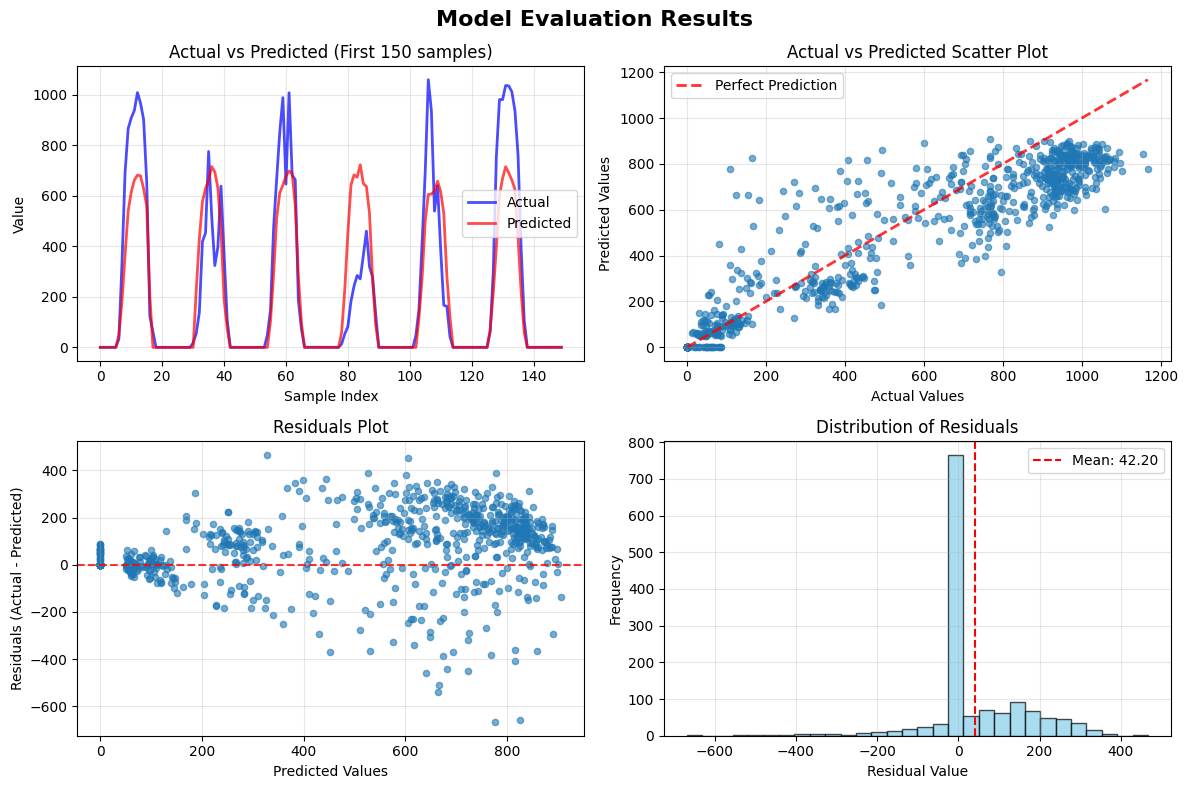

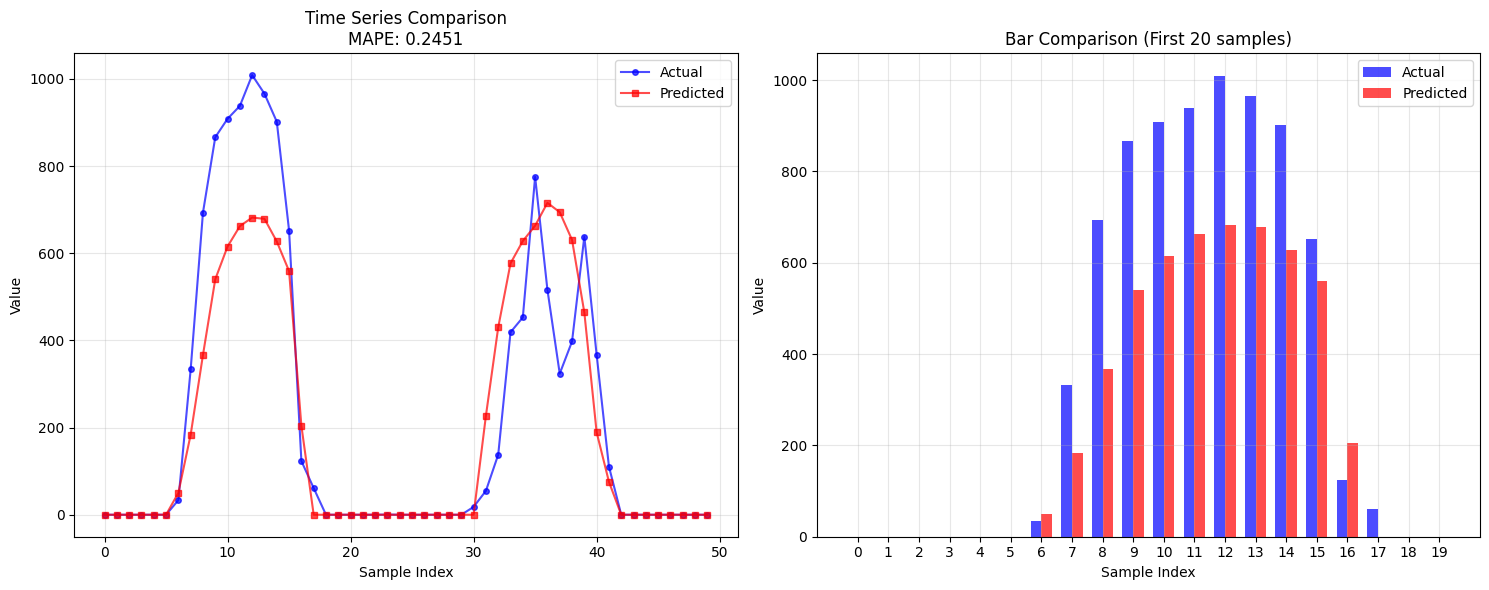

MODEL EVALUATION SUMMARY
Total samples: 1392
Overall MAPE: 0.2451
Mean Absolute Error: 72.9533
Root Mean Square Error: 126.7048
Mean Residual: 42.1973
Std Residual: 119.4718
Min Residual: -668.2200
Max Residual: 466.7180
Predictions set to 0 (< 50): 719/1392 (51.7%)
CatBoostRegressor MAPE loss : 24.50875903887077


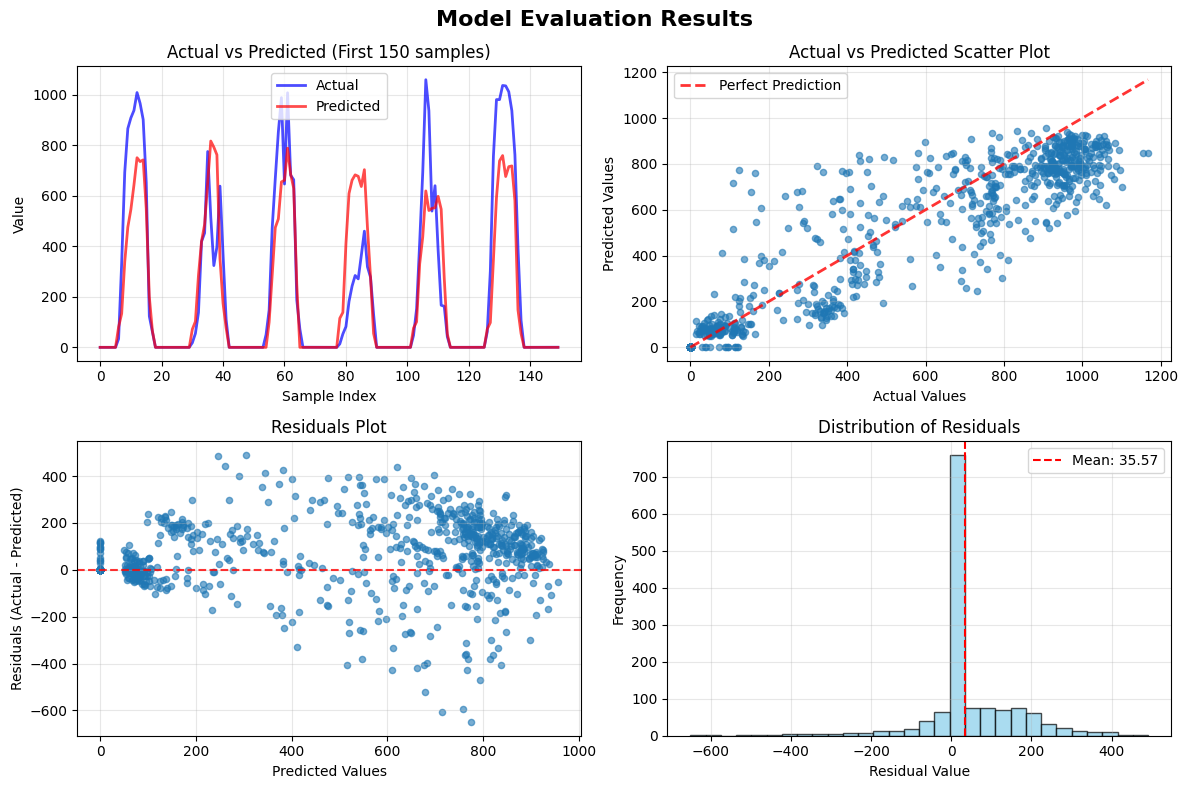

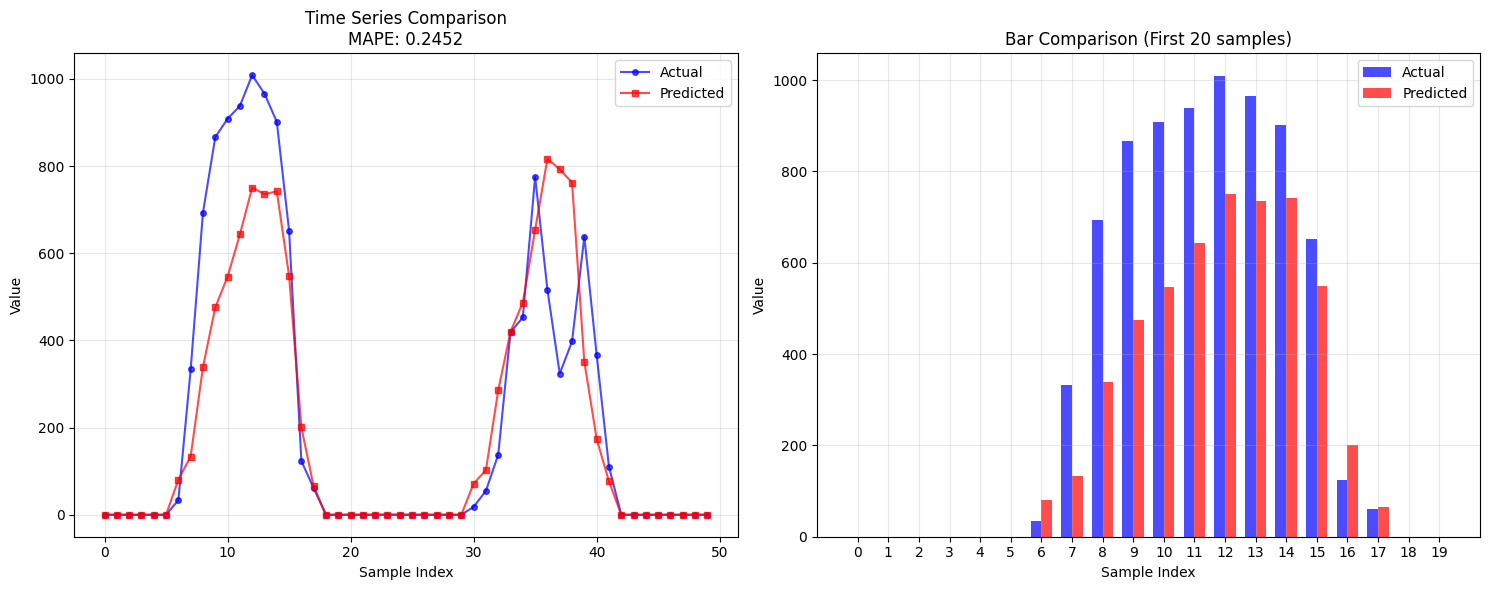

MODEL EVALUATION SUMMARY
Total samples: 1392
Overall MAPE: 0.2452
Mean Absolute Error: 69.7392
Root Mean Square Error: 125.1683
Mean Residual: 35.5668
Std Residual: 120.0088
Min Residual: -650.7634
Max Residual: 490.9437
Predictions set to 0 (< 50): 709/1392 (50.9%)
LGBMRegressor MAPE loss : 24.52105485432684%


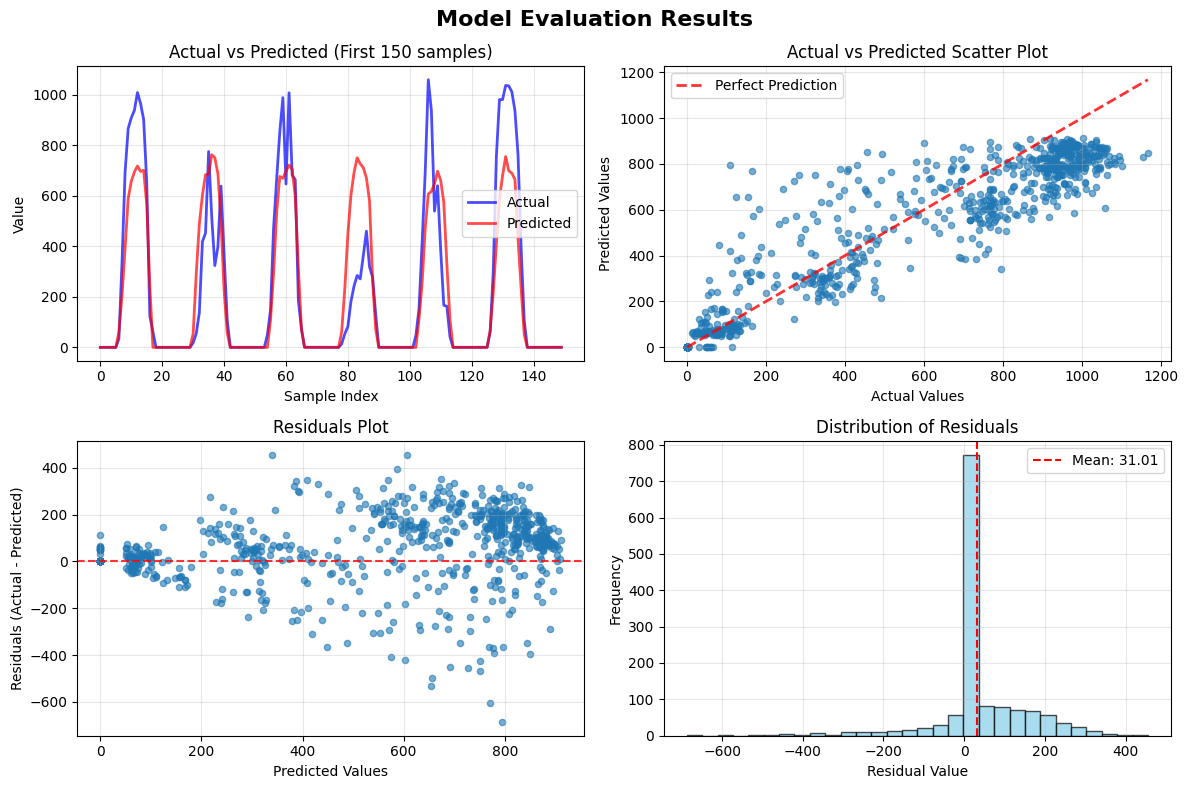

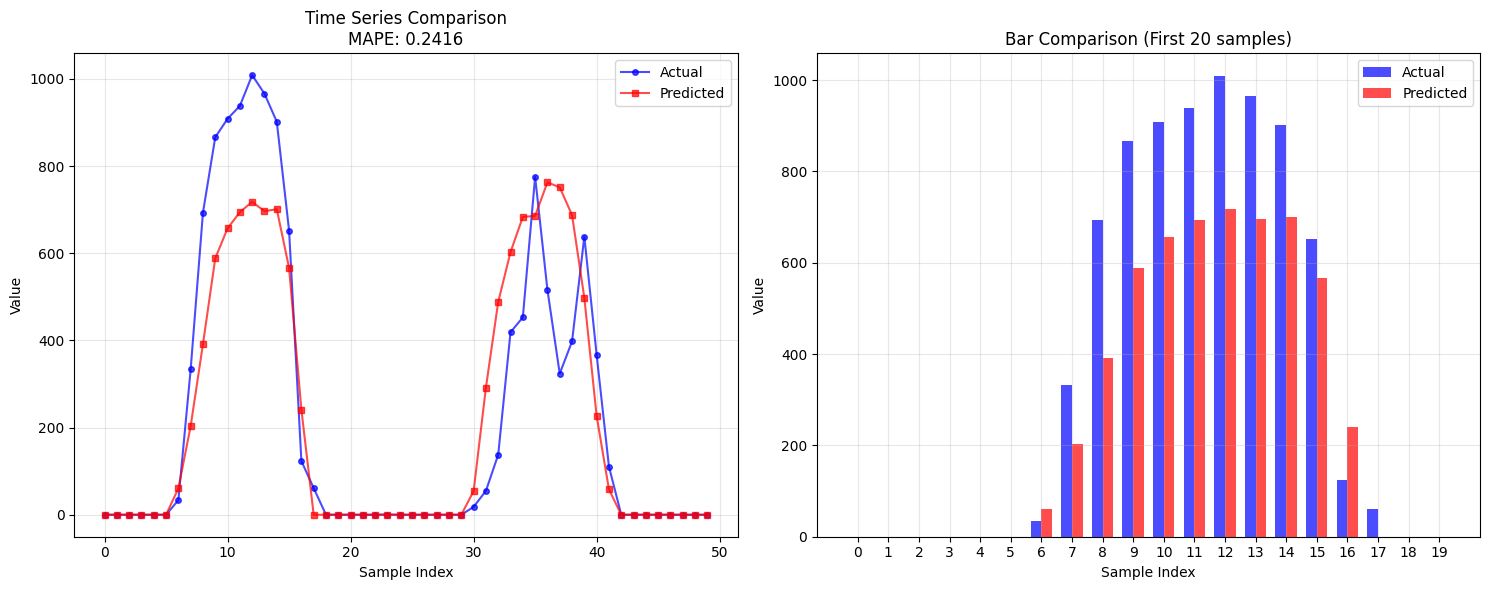

MODEL EVALUATION SUMMARY
Total samples: 1392
Overall MAPE: 0.2416
Mean Absolute Error: 66.4196
Root Mean Square Error: 118.2641
Mean Residual: 31.0106
Std Residual: 114.1260
Min Residual: -687.2724
Max Residual: 455.3023
Predictions set to 0 (< 50): 707/1392 (50.8%)
RandomForestRegressor MAPE loss : 24.164484018037975%


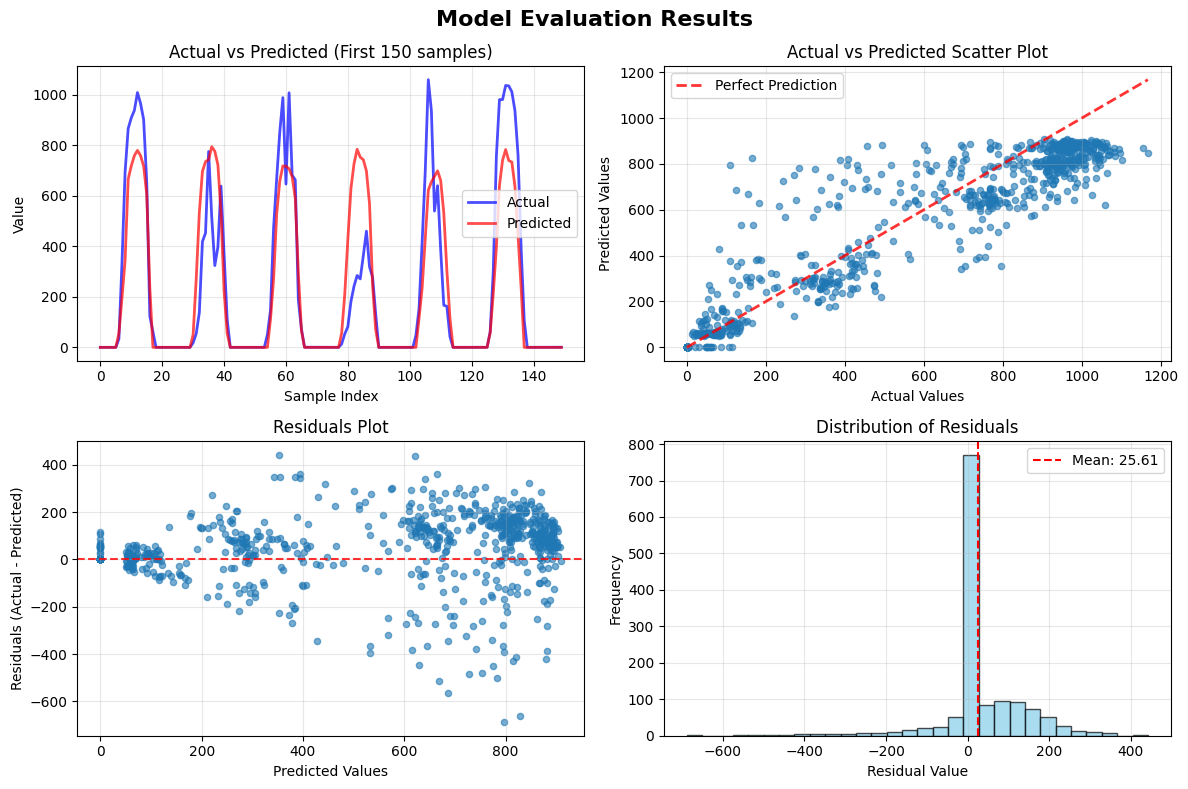

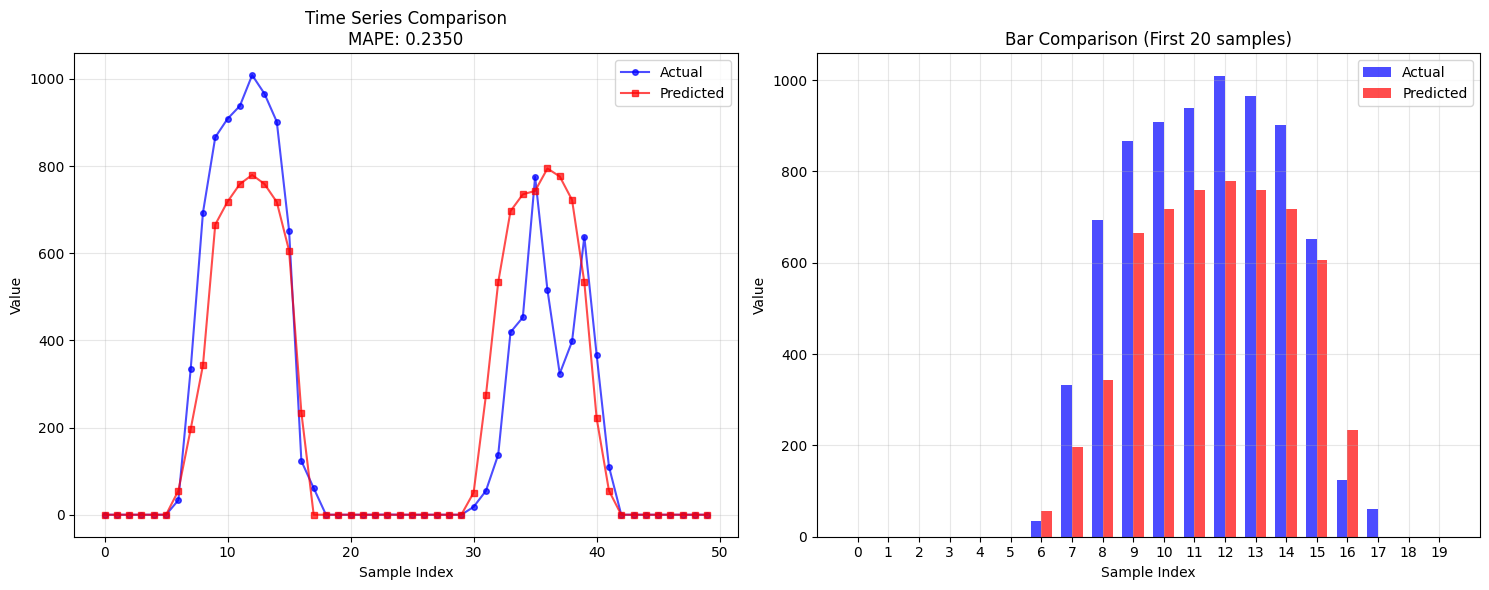

MODEL EVALUATION SUMMARY
Total samples: 1392
Overall MAPE: 0.2350
Mean Absolute Error: 62.3621
Root Mean Square Error: 112.9198
Mean Residual: 25.6144
Std Residual: 109.9763
Min Residual: -688.4981
Max Residual: 442.3177
Predictions set to 0 (< 50): 710/1392 (51.0%)
ExtraTreesRegressor MAPE loss : 23.496954488731397%


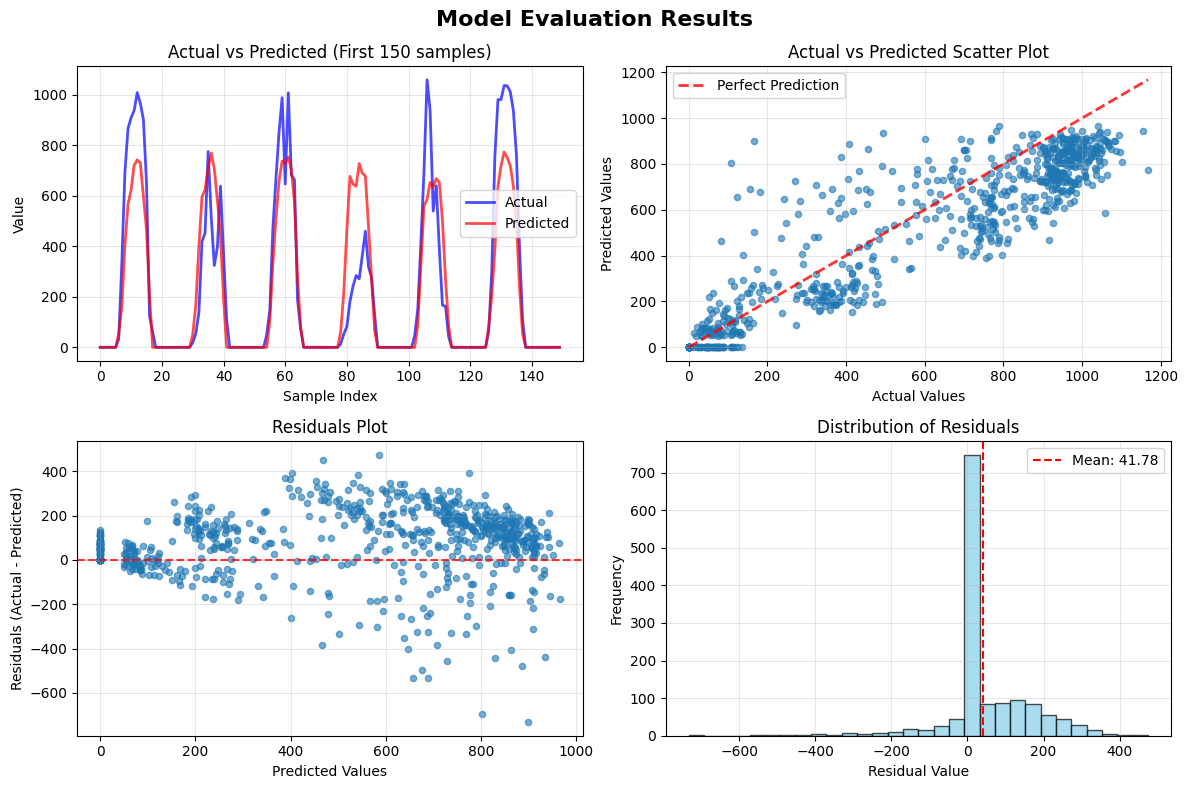

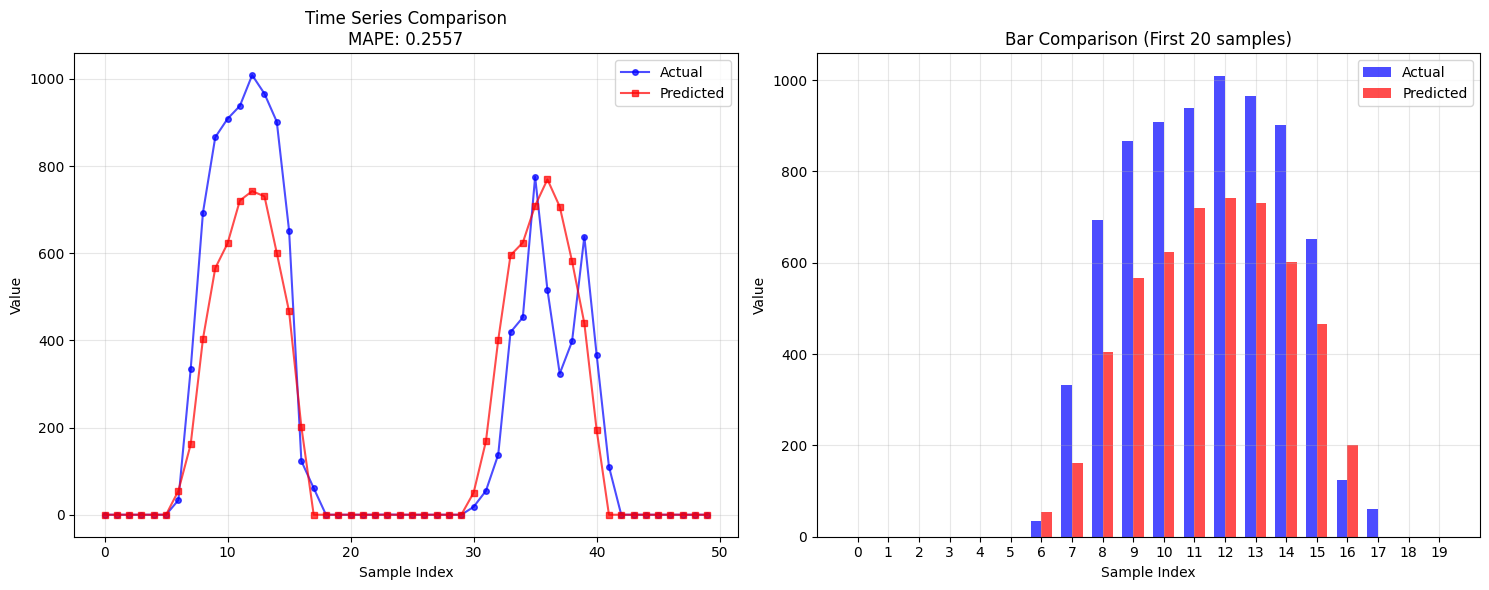

MODEL EVALUATION SUMMARY
Total samples: 1392
Overall MAPE: 0.2557
Mean Absolute Error: 72.3213
Root Mean Square Error: 125.2602
Mean Residual: 41.7751
Std Residual: 118.0888
Min Residual: -732.8119
Max Residual: 474.2207
Predictions set to 0 (< 50): 749/1392 (53.8%)
GradientBoostingRegressor MAPE loss : 25.571628045941573%


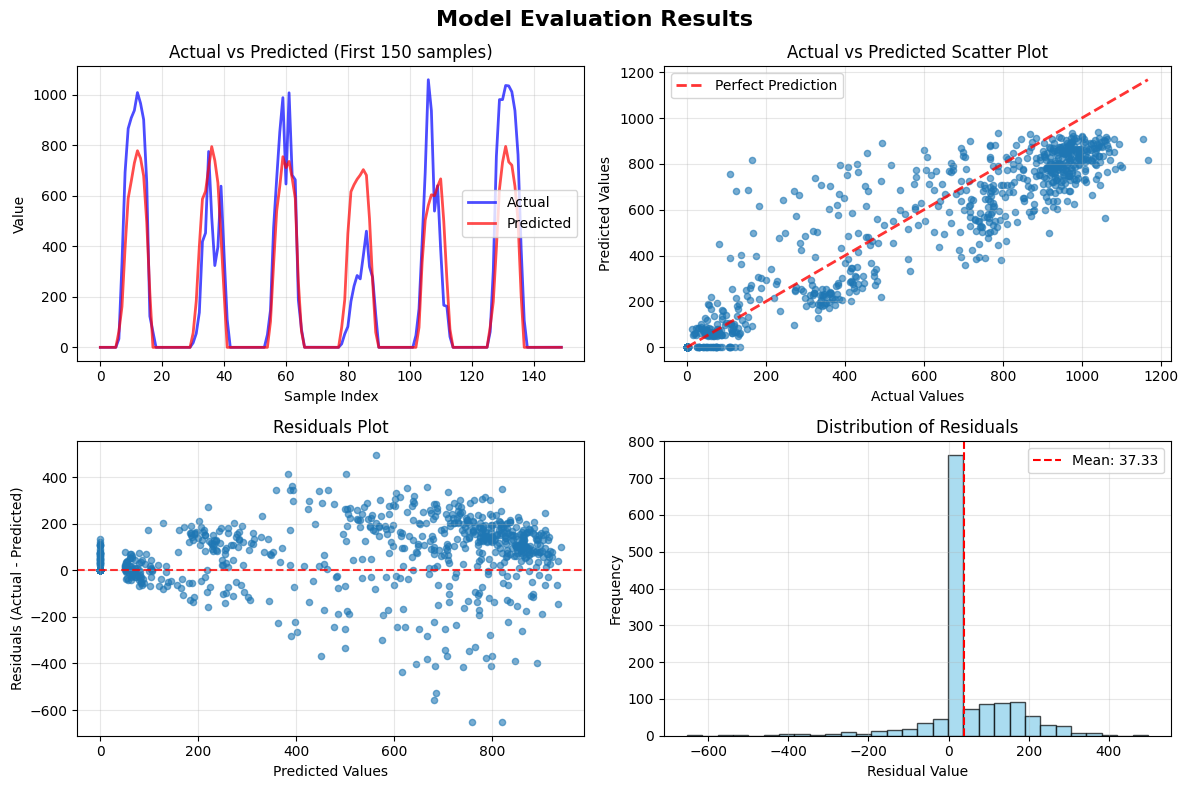

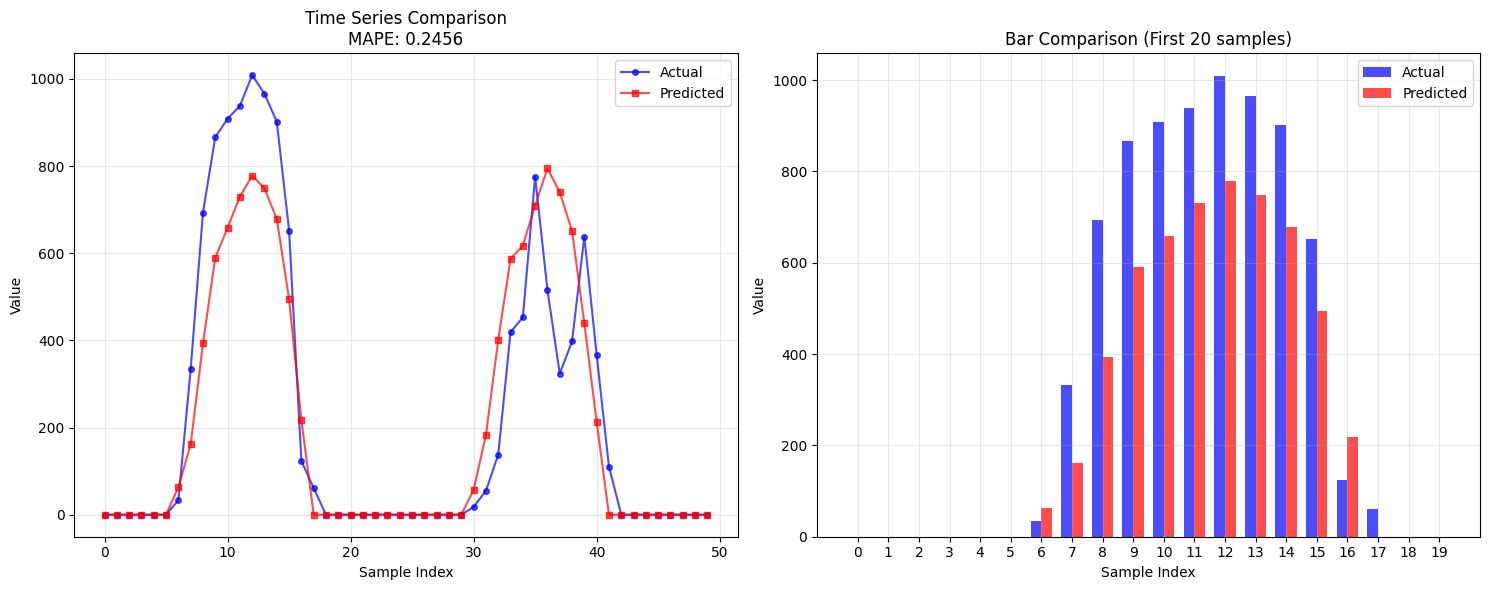

MODEL EVALUATION SUMMARY
Total samples: 1392
Overall MAPE: 0.2456
Mean Absolute Error: 68.8218
Root Mean Square Error: 119.4734
Mean Residual: 37.3296
Std Residual: 113.4918
Min Residual: -652.9987
Max Residual: 497.3382
Predictions set to 0 (< 50): 728/1392 (52.3%)
StackingRegressor MAPE loss : 24.560957555303673%


In [7]:
catboost_compiler = score_compiler(catboost, test_x, test_y)
catboost_y_pred, catboost_mape_loss, catboost_total_loss = catboost_compiler.evaluate(plot=True, n_samples=150)
catboost_compiler.create_detailed_comparison_plot(n_samples=50)
catboost_compiler.print_evaluation_summary()
print(f'CatBoostRegressor MAPE loss : {catboost_total_loss*100}')

LGBM_R_compiler = score_compiler(LGBM_R, test_x, test_y)
LGBM_R_y_pred, LGBM_R_mape_loss, LGBM_R_total_loss = LGBM_R_compiler.evaluate(plot=True, n_samples=150)
LGBM_R_compiler.create_detailed_comparison_plot(n_samples=50)
LGBM_R_compiler.print_evaluation_summary()
print(f'LGBMRegressor MAPE loss : {LGBM_R_total_loss*100}%')

random_compiler = score_compiler(random_forest, test_x, test_y)
random_y_pred, random_mape_loss, random_total_loss = random_compiler.evaluate(plot=True, n_samples=150)
random_compiler.create_detailed_comparison_plot(n_samples=50)
random_compiler.print_evaluation_summary()
print(f'RandomForestRegressor MAPE loss : {random_total_loss*100}%')

extra_compiler = score_compiler(extra_trees, test_x, test_y)
extra_y_pred, extra_mape_loss, extra_total_loss = extra_compiler.evaluate(plot=True, n_samples=150)
extra_compiler.create_detailed_comparison_plot(n_samples=50)
extra_compiler.print_evaluation_summary()
print(f'ExtraTreesRegressor MAPE loss : {extra_total_loss*100}%')

Gradient_compiler = score_compiler(GradientBoosting, test_x, test_y)
Gradient_y_pred, Gradient_mape_loss, Gradient_total_loss = Gradient_compiler.evaluate(plot=True, n_samples=150)
Gradient_compiler.create_detailed_comparison_plot(n_samples=50)
Gradient_compiler.print_evaluation_summary()
print(f'GradientBoostingRegressor MAPE loss : {Gradient_total_loss*100}%')

model_0_compiler = score_compiler(model_0, test_x, test_y)
model_0_y_pred, model_0_mape_loss, model_0_total_loss = model_0_compiler.evaluate(plot=True, n_samples=150)
model_0_compiler.create_detailed_comparison_plot(n_samples=50)
model_0_compiler.print_evaluation_summary()
print(f'StackingRegressor MAPE loss : {model_0_total_loss*100}%')

In [8]:
def predict(config):
    final=(numpy.array(catboost_y_pred)*config['catboost']+
           numpy.array(LGBM_R_y_pred)*config['LGBM_R']+
           numpy.array(random_y_pred)*config['random']+
           numpy.array(extra_y_pred)*config['extra']+
           numpy.array(Gradient_y_pred)*config['Gradient']+
           numpy.array(model_0_y_pred)*config['model_0'])

    final/=sum(config.values())

    score = mean_absolute_percentage_error(test_y, final)*100
    r2 = r2_score(test_y, final)
    print(f"R² Score: {r2:}")
    print(f"MAPE Score: {100-score:}")
    return final

def submission_compiler(y_pred, test_y):
    mape_loss = []
    total_loss = mean_absolute_percentage_error(test_y, y_pred)
    for actual, predected in zip(y_pred, test_y):
        mape_loss.append(mean_absolute_percentage_error([predected], [actual]))
    return y_pred, numpy.array(mape_loss), total_loss

config={
    "catboost" : 0.4,
    "LGBM_R"   : 0.3,
    "random"   : 0.5,
    "extra"    : 0.4,
    "Gradient" : 0.3,
    "model_0"  : -0.2
}

final_y_pre = predict(config)
final_y_pred, final_mape_loss, final_total_loss = submission_compiler(final_y_pre, test_y)
print(f'MAPE Loss : {final_total_loss*100}%')

R² Score: 0.9109651700400898
MAPE Score: 76.59020678384809
MAPE Loss : 23.40979321615191%


In [9]:
def compute_monthwise_mape(submission_df):
    df = submission_df.copy()
    if not pd.api.types.is_datetime64_any_dtype(df['timestamp']):
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        
    df['year_month'] = df['timestamp'].dt.to_period('M')
    monthly_mape = df.groupby('year_month').agg({
        'mape': ['mean']
    })

    monthly_mape.columns = ['month_mape']
    monthly_mape = monthly_mape.reset_index()
    
    return monthly_mape

submission = pandas.DataFrame({'timestamp' : test['timestamp'], 
                               'predicted_ghi' : final_y_pred,
                               'actual_ghi' : test_y,
                               'mape' : final_mape_loss})

month_submission = compute_monthwise_mape(submission)

print(f"\nOverall statistics:")
print(f"Average monthly MAPE (Method 1): {month_submission['month_mape'].mean():.2f}%")


Overall statistics:
Average monthly MAPE (Method 1): 0.24%


In [10]:
submission.to_csv(f"Vigneshwaran.csv", index=False)
month_submission.to_csv(f"Month_Vigneshwaran.csv", index=False)

In [11]:
submission

,timestamp,predicted_ghi,actual_ghi,mape
0,1/1/2025 0:00,0.0,0.0,0.0
1,1/1/2025 1:00,0.0,0.0,0.0
2,1/1/2025 2:00,0.0,0.0,0.0
3,1/1/2025 3:00,0.0,0.0,0.0
4,1/1/2025 4:00,0.0,0.0,0.0
...,...,...,...,...
1387,2/27/2025 19:00,0.0,0.0,0.0
1388,2/27/2025 20:00,0.0,0.0,0.0
1389,2/27/2025 21:00,0.0,0.0,0.0
1390,2/27/2025 22:00,0.0,0.0,0.0


In [12]:
month_submission

,year_month,month_mape
0,2025-01,0.216230
1,2025-02,0.254613
